# This is a notebook for making plots

### Setup
Let's load the data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data from the CSV file
results_path = "./big_test_2/big_test_aggregate_comparison_test_2025-04-10_18-32-54.csv"
df = pd.read_csv(results_path)

# Display the first few rows to understand the data structure
print(f"Loaded data from {results_path}")
print(f"Data shape: {df.shape}")
print("\nFirst few rows:")
df.head(10)


Loaded data from ./big_test_2/big_test_aggregate_comparison_test_2025-04-10_18-32-54.csv
Data shape: (20, 14)

First few rows:


,Dimension,Model Type,Bayesian,Supervised,Target Class Confidence (Before),Target Class Confidence (After),Confidence Increase,Latent Target Class Confidence (After),Success Rate,Soft Success Rate,Avg Latent Distance,Avg Log Likelihood Difference,Avg Realism Score Difference,Avg IM1 Score
0,16,Supervised Deterministic,False,True,NaN,0.078901,NaN,0.319987,0.08,0.04,12.613275,28.502780,0.012765,8.859754
1,16,Unsupervised Deterministic,False,False,NaN,0.519914,NaN,0.519914,0.52,0.26,7.828064,19.185205,0.007891,14.881641
2,16,Supervised Bayesian,True,True,NaN,0.601433,NaN,0.669364,0.78,0.44,55.002081,48.369957,0.023538,0.923871
3,16,Unsupervised Bayesian,True,False,NaN,0.939023,NaN,0.939023,0.98,0.49,17.626565,38.250267,0.018903,0.993196
4,32,Supervised Deterministic,False,True,NaN,0.084242,NaN,0.240000,0.08,0.04,11.290238,14.896719,0.005491,15.542948
5,32,Unsupervised Deterministic,False,False,NaN,0.459953,NaN,0.459953,0.46,0.23,8.608552,22.113160,0.012779,16.723864
6,32,Supervised Bayesian,True,True,NaN,0.624761,NaN,0.841356,0.76,0.40,60.630598,38.664312,0.016716,1.139640
7,32,Unsupervised Bayesian,True,False,NaN,0.957075,NaN,0.957075,0.98,0.49,20.969599,55.387634,0.043500,0.652846
8,64,Supervised Deterministic,False,True,NaN,0.040085,NaN,0.280000,0.04,0.02,15.263971,11.042520,0.004676,17.538259
9,64,Unsupervised Deterministic,False,False,NaN,0.579987,NaN,0.579987,0.58,0.29,13.622988,36.704588,0.019448,8.102690


In [4]:
# Define your preferred order
model_type_order = [
    "Unsupervised Deterministic",
    "Supervised Deterministic", 
    "Unsupervised Bayesian",
    "Supervised Bayesian"
]

# Convert the column to categorical type with your order
df['Model Type'] = pd.Categorical(
    df['Model Type'],
    categories=model_type_order,
    ordered=True
)


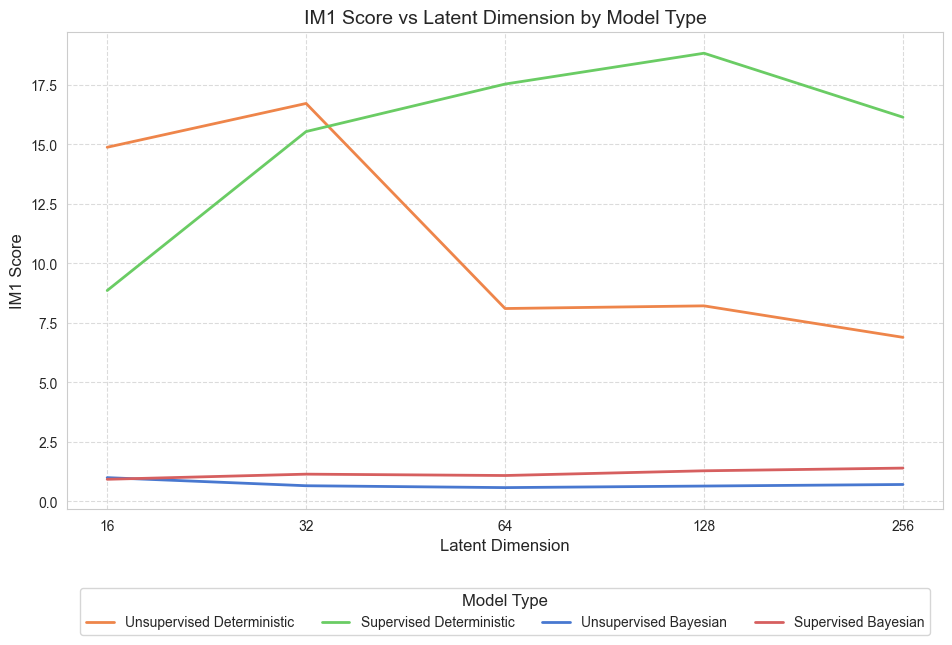

In [3]:
# Create a plot for IM1 Score * Realism vs Dimensions
plt.figure(figsize=(10, 7))

# Set up the style
sns.set_style("whitegrid")

# Extract model types and dimensions
model_types = df['Model Type'].unique()
dims = sorted(df['Dimension'].unique())

# Create color palette with specified colors in muted tones
palette = sns.color_palette("muted", 4)
# Reorder the palette to green, orange, blue, red
custom_palette = [palette[1], palette[2], palette[0], palette[3]]  # green, orange, blue, red in muted tones

# Create a line plot using seaborn
ax = sns.lineplot(
    x='Dimension', 
    y='Avg IM1 Score', 
    hue='Model Type',
    data=df,
    markers=['o', 's', '^', 'D'],
    palette=custom_palette,
    linewidth=2,
    markersize=8
)

# Add labels and title
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('IM1 Score', fontsize=12)
plt.title('IM1 Score vs Latent Dimension by Model Type', fontsize=14)

# Set x-axis to log scale since dimensions increase exponentially
plt.xscale('log', base=2)
plt.xticks(dims, labels=dims)

# Adjust legend - place it at the bottom
plt.legend(title='Model Type', fontsize=10, title_fontsize=12, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=len(model_types))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make room for legend
plt.show()


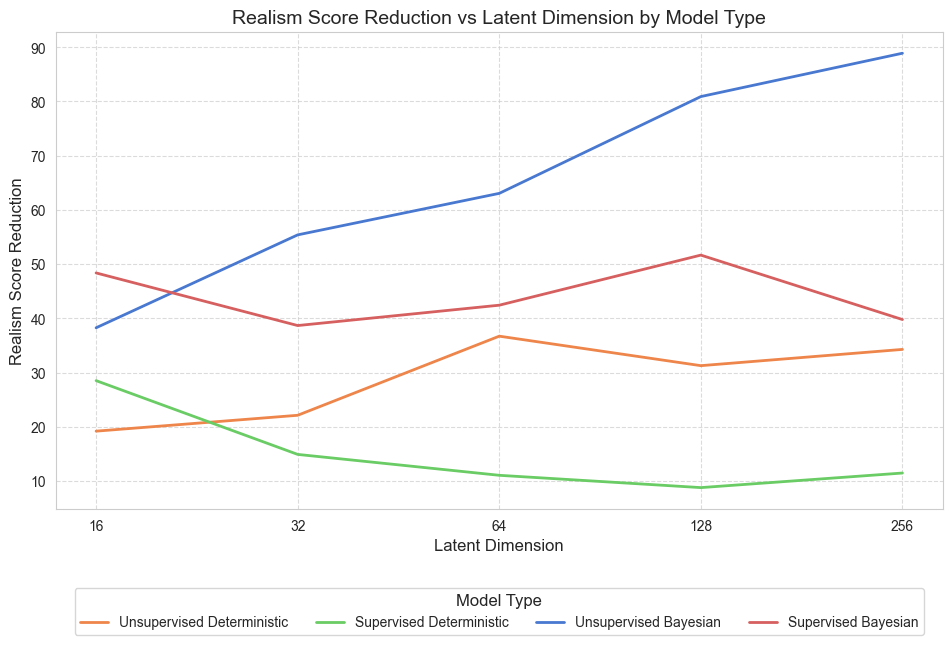

In [ ]:
# Create a plot for IM1 Score * Realism vs Dimensions
plt.figure(figsize=(10, 7))

# Set up the style
sns.set_style("whitegrid")

# Extract model types and dimensions
model_types = df['Model Type'].unique()
dims = sorted(df['Dimension'].unique())

# Create color palette with specified colors in muted tones
palette = sns.color_palette("muted", 4)
# Reorder the palette to green, orange, blue, red
custom_palette = [palette[1], palette[2], palette[0], palette[3]]  # green, orange, blue, red in muted tones

# Create a line plot using seaborn
ax = sns.lineplot(
    x='Dimension', 
    y='Avg Realism Score Difference', 
    hue='Model Type',
    data=df,
    markers=['o', 's', '^', 'D'],
    palette=custom_palette,
    linewidth=2,
    markersize=8
)

# Add labels and title
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Realism Score Reduction', fontsize=12)
plt.title('Realism Score Reduction vs Latent Dimension by Model Type', fontsize=14)

# Set x-axis to log scale since dimensions increase exponentially
plt.xscale('log', base=2)
plt.xticks(dims, labels=dims)

# Adjust legend - place it at the bottom
plt.legend(title='Model Type', fontsize=10, title_fontsize=12, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=len(model_types))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make room for legend
plt.show()


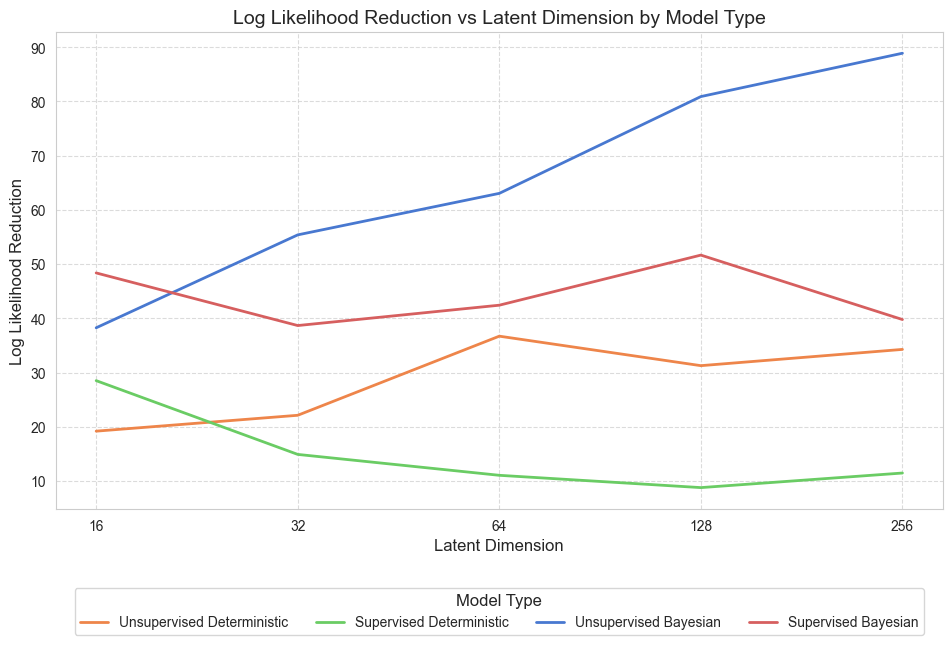

In [6]:
# Create a plot for IM1 Score * Realism vs Dimensions
plt.figure(figsize=(10, 7))

# Set up the style
sns.set_style("whitegrid")

# Extract model types and dimensions
model_types = df['Model Type'].unique()
dims = sorted(df['Dimension'].unique())

# Create color palette with specified colors in muted tones
palette = sns.color_palette("muted", 4)
# Reorder the palette to green, orange, blue, red
custom_palette = [palette[1], palette[2], palette[0], palette[3]]  # green, orange, blue, red in muted tones

# Create a line plot using seaborn
ax = sns.lineplot(
    x='Dimension', 
    y='Avg Log Likelihood Difference', 
    hue='Model Type',
    data=df,
    markers=['o', 's', '^', 'D'],
    palette=custom_palette,
    linewidth=2,
    markersize=8
)

# Add labels and title
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Log Likelihood Reduction', fontsize=12)
plt.title('Log Likelihood Reduction vs Latent Dimension by Model Type', fontsize=14)

# Set x-axis to log scale since dimensions increase exponentially
plt.xscale('log', base=2)
plt.xticks(dims, labels=dims)

# Adjust legend - place it at the bottom
plt.legend(title='Model Type', fontsize=10, title_fontsize=12, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=len(model_types))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make room for legend
plt.show()


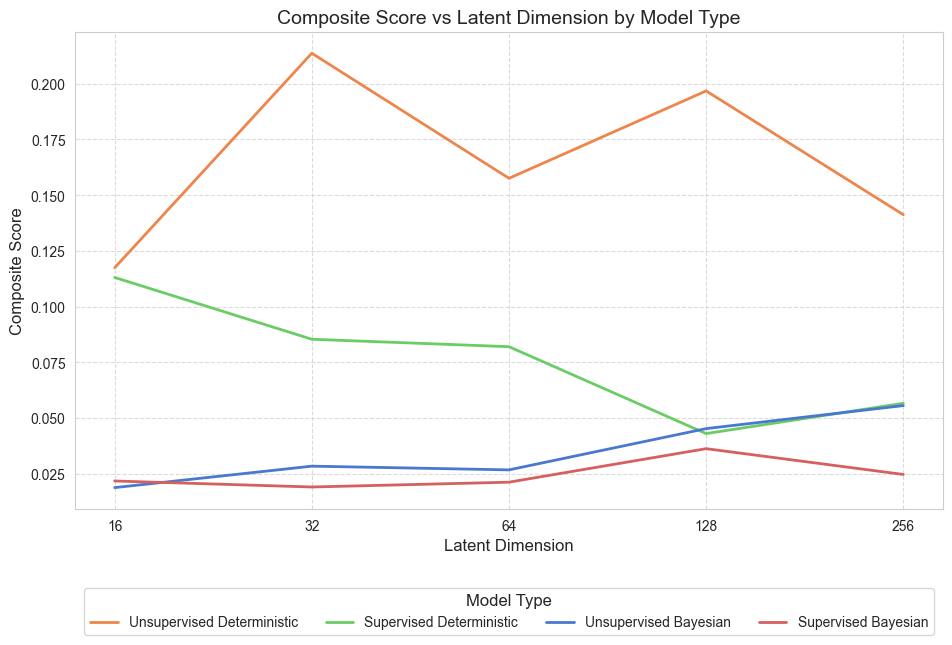

In [5]:
# Create a plot for IM1 Score * Realism vs Dimensions
plt.figure(figsize=(10, 7))

# Set up the style
sns.set_style("whitegrid")

# Extract model types and dimensions
model_types = df['Model Type'].unique()
dims = sorted(df['Dimension'].unique())

# Create color palette with specified colors in muted tones
palette = sns.color_palette("muted", 4)
# Reorder the palette to green, orange, blue, red
custom_palette = [palette[1], palette[2], palette[0], palette[3]]  # green, orange, blue, red in muted tones

# Calculate IM1 Score * Realism
df['IM1_Realism_Product'] = df['Avg IM1 Score'] * df['Avg Realism Score Difference']

# Create a line plot using seaborn
ax = sns.lineplot(
    x='Dimension', 
    y='IM1_Realism_Product', 
    hue='Model Type',
    data=df,
    markers=['o', 's', '^', 'D'],
    palette=custom_palette,
    linewidth=2,
    markersize=8
)

# Add labels and title
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Composite Score', fontsize=12)
plt.title('Composite Score vs Latent Dimension by Model Type', fontsize=14)

# Set x-axis to log scale since dimensions increase exponentially
plt.xscale('log', base=2)
plt.xticks(dims, labels=dims)

# Adjust legend - place it at the bottom
plt.legend(title='Model Type', fontsize=10, title_fontsize=12, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=len(model_types))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make room for legend
plt.show()


Unique model types after filtering: ['Supervised Bayesian', 'Unsupervised Bayesian']
Categories (4, object): ['Unsupervised Deterministic' < 'Supervised Deterministic' < 'Unsupervised Bayesian' < 'Supervised Bayesian']
Number of unique model types: 2


/var/folders/tb/ccwl9r592hn9v_xpq9s1bzlr0000gn/T/ipykernel_43652/976840669.py:29: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(


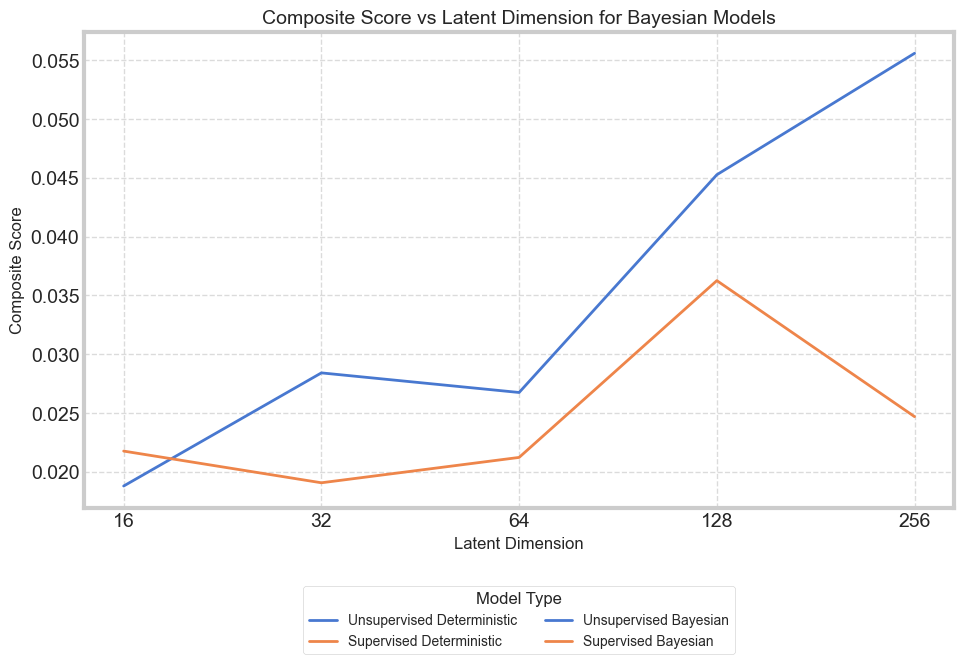

In [65]:
# Filter the DataFrame to only include Bayesian models
bayesian_df = df[df['Model Type'].str.contains('Bayesian')].copy()  # Make a copy to avoid modifying original

# Reset the categorical variable to only include the filtered values
bayesian_model_types = bayesian_df['Model Type'].unique()
bayesian_df['Model Type'] = pd.Categorical(bayesian_df['Model Type'], categories=bayesian_model_types)

# Print to verify we only have 2 categories
print("Unique model types after filtering:", bayesian_model_types)
print("Number of unique model types:", len(bayesian_model_types))

# Create a plot
plt.figure(figsize=(10, 7))

# Set up the style
sns.set_style("whitegrid")

# Extract dimensions
dims = sorted(bayesian_df['Dimension'].unique())

# Create a specific palette for just the Bayesian models
bayesian_palette = sns.color_palette("muted")[0:2]  # Just take 2 colors

# Calculate IM1 Score * Realism (if not already calculated)
if 'IM1_Realism_Product' not in bayesian_df.columns:
    bayesian_df['IM1_Realism_Product'] = bayesian_df['Avg IM1 Score'] * bayesian_df['Avg Realism Score Difference']

# Create a line plot using seaborn
ax = sns.lineplot(
    x='Dimension', 
    y='IM1_Realism_Product', 
    hue='Model Type',
    data=bayesian_df,
    markers=['o', '^'],
    palette=bayesian_palette,
    linewidth=2,
    markersize=8
)

# Add labels and title
plt.xlabel('Latent Dimension', fontsize=12)
plt.ylabel('Composite Score', fontsize=12)
plt.title('Composite Score vs Latent Dimension for Bayesian Models', fontsize=14)

# Set x-axis to log scale since dimensions increase exponentially
plt.xscale('log', base=2)
plt.xticks(dims, labels=dims)

# Adjust legend
plt.legend(title='Model Type', fontsize=10, title_fontsize=12, loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), ncol=len(bayesian_model_types))

plt.grid(True, linestyle='--', alpha=0.7)
plt.subplots_adjust(bottom=0.2)
plt.show()

In [6]:
import os
import pandas as pd
import re
import glob

def load_all_individual_results(base_dir="./big_test_2/individual_results"):
    """
    Loads all individual results CSVs from subfolders into a structured format.
    
    Args:
        base_dir: Path to the parent directory containing result folders
        
    Returns:
        dict: Dictionary with structure {dimension: {model_type: DataFrame}}
    """
    # Dictionary to store all results
    all_results = {}
    
    # Pattern to match folder names and extract dimension and model type
    folder_pattern = r"big_test_(\d+)_([^_]+(?:_[^_]+)?)_\d{4}-\d{2}-\d{2}"
    
    # Find all subdirectories
    subdirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    
    # Process each subdirectory
    for subdir in subdirs:
        # Extract dimension and model type from folder name
        match = re.match(folder_pattern, subdir)
        if not match:
            print(f"Skipping directory with unrecognized format: {subdir}")
            continue
            
        dimension, model_type = match.groups()
        dimension = int(dimension)  # Convert to integer
        
        # Path to the CSV file
        csv_path = os.path.join(base_dir, subdir, "individual_results.csv")
        
        # Check if CSV file exists
        if not os.path.exists(csv_path):
            print(f"CSV file not found in {subdir}, skipping.")
            continue
            
        # Load CSV data
        try:
            df = pd.read_csv(csv_path)
            
            # Add dimension and model_type columns
            df['dimension'] = dimension
            df['model_type'] = model_type
            
            # Store in our structure
            if dimension not in all_results:
                all_results[dimension] = {}
                
            all_results[dimension][model_type] = df
            print(f"Loaded {len(df)} records from {subdir}")
            
        except Exception as e:
            print(f"Error loading CSV from {subdir}: {e}")
    
    return all_results

In [7]:
results_dict = load_all_individual_results()


Loaded 50 records from big_test_32_Supervised Bayesian_2025-04-10_17-33-37
Loaded 50 records from big_test_32_Unsupervised Deterministic_2025-04-10_17-27-23
Loaded 50 records from big_test_128_Supervised Deterministic_2025-04-10_17-55-55
Loaded 50 records from big_test_32_Supervised Deterministic_2025-04-10_17-26-12
Loaded 50 records from big_test_128_Supervised Bayesian_2025-04-10_18-03-24
Loaded 50 records from big_test_16_Supervised Bayesian_2025-04-10_17-18-43
Loaded 50 records from big_test_256_Supervised Bayesian_2025-04-10_18-18-18
Loaded 50 records from big_test_256_Supervised Deterministic_2025-04-10_18-10-46
Loaded 50 records from big_test_64_Supervised Bayesian_2025-04-10_17-48-28
Loaded 50 records from big_test_16_Supervised Deterministic_2025-04-10_17-11-05
Loaded 50 records from big_test_64_Unsupervised Bayesian_2025-04-10_17-55-03
Loaded 50 records from big_test_32_Unsupervised Bayesian_2025-04-10_17-40-09
Loaded 50 records from big_test_64_Unsupervised Deterministic_202

In [10]:
def calculate_failure_rates(results_dict, threshold=1e-6):
    """
    Calculates failure rates for each dimension and model type.
    Failure is defined as target_class_confidence being below threshold.
    
    Args:
        results_dict: Dictionary with structure {dimension: {model_type: DataFrame}}
        threshold: Minimum value for target_class_confidence to be considered successful
        
    Returns:
        DataFrame: Containing dimension, model_type, and failure_rate columns
    """
    failure_data = []
    
    for dimension, models in results_dict.items():
        for model_type, df in models.items():
            # Check if target_class_confidence exists in the DataFrame
            if 'target_class_confidence' not in df.columns:
                print(f"Warning: target_class_confidence not found in {dimension} {model_type}")
                continue
                
            # Calculate failure rate
            total_count = len(df)
            failure_count = len(df[df['target_class_confidence'] <= threshold])
            failure_rate = failure_count / total_count if total_count > 0 else np.nan
            
            failure_data.append({
                'dimension': dimension,
                'model_type': model_type,
                'failure_rate': failure_rate,
                'sample_count': total_count
            })
    
    return pd.DataFrame(failure_data)

def plot_failure_rates(failure_df):
    """
    Creates plots of failure rates across dimensions and model types.
    
    Args:
        failure_df: DataFrame with dimension, model_type, and failure_rate columns
    """
    # Set up the style
    sns.set_style("whitegrid")
    
    # Use the predefined model type order
    model_types = model_type_order
    dims = sorted(failure_df['dimension'].unique())
    
   # Create color palette with specified colors in muted tones
    palette = sns.color_palette("muted", 4)
    # Reorder the palette to green, orange, blue, red
    custom_palette = [palette[1], palette[2], palette[0], palette[3]]  # green, orange, blue, red in muted tones
    
    # Plot 1: Bar chart comparing failure rates by dimension and model type
    plt.figure(figsize=(14, 8))
    
    # Use the order parameter to ensure consistent ordering
    ax = sns.barplot(x='dimension', y='failure_rate', hue='model_type', data=failure_df, 
                    palette=custom_palette, hue_order=model_types)
    
    plt.title('Counterfactual Failure Rate by Dimension and Model Type', fontsize=18)
    plt.xlabel('Latent Dimension', fontsize=16)
    plt.ylabel('Failure Rate (target confidence < 1e-6)', fontsize=16)
    plt.ylim(0, 1)  # Failure rate is between 0 and 1
    
    # Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=12)
    
    # Adjust legend and tick labels
    plt.legend(title='Model Type', fontsize=14, title_fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Line chart showing failure rate trends across dimensions
    plt.figure(figsize=(14, 8))
    
    # Pivot the data for line plot
    pivot_df = failure_df.pivot(index='dimension', columns='model_type', values='failure_rate')
    
    # Plot each model type as a line, using the predefined order
    for i, model_type in enumerate(model_types):
        if model_type in pivot_df.columns:
            plt.plot(dims, pivot_df[model_type], marker='o', linewidth=2, 
                    label=model_type, color=custom_palette[i])
    
    plt.title('Failure Rate Trends Across Dimensions', fontsize=18)
    plt.xlabel('Latent Dimension', fontsize=16)
    plt.ylabel('Failure Rate', fontsize=16)
    plt.xticks(dims, fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Model Type', fontsize=14, title_fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Return the DataFrame for further analysis
    return failure_df

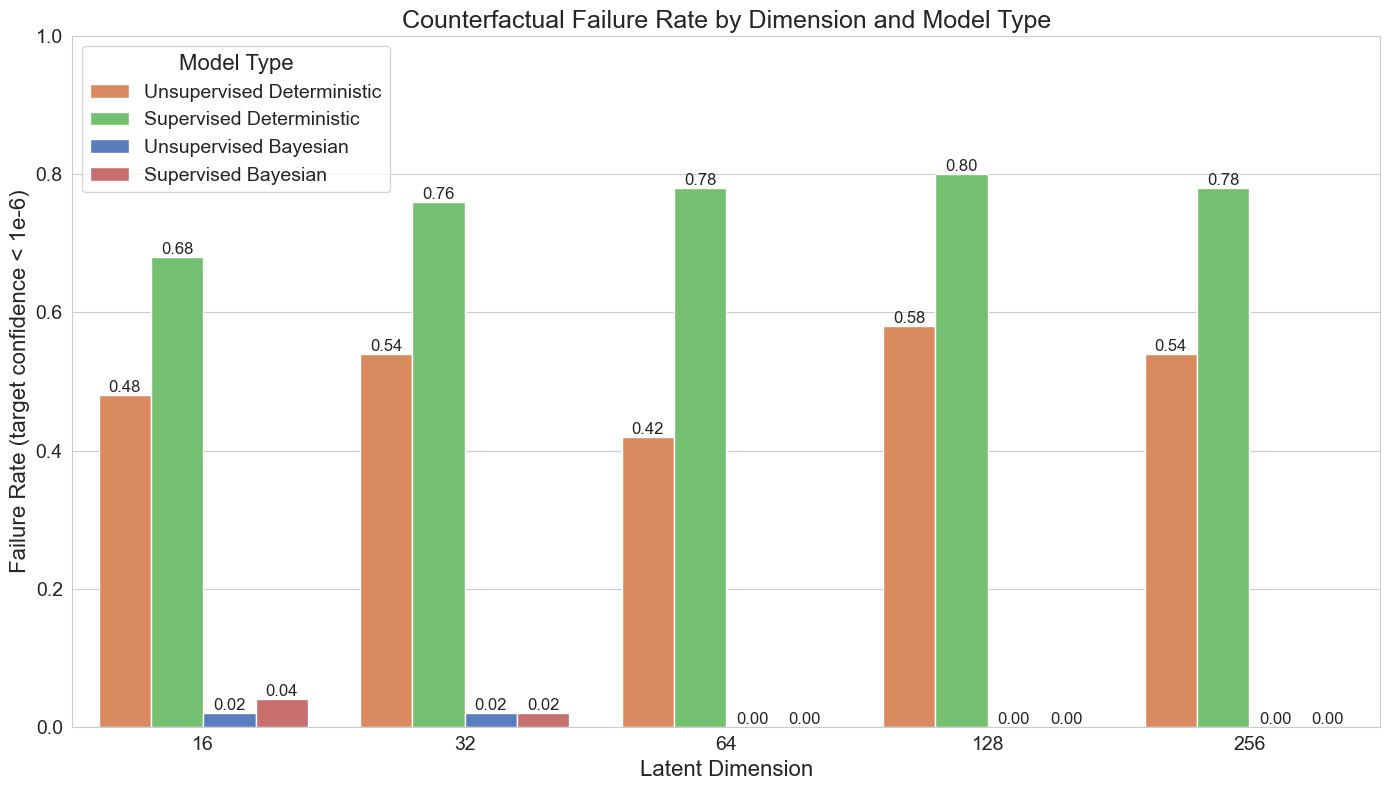

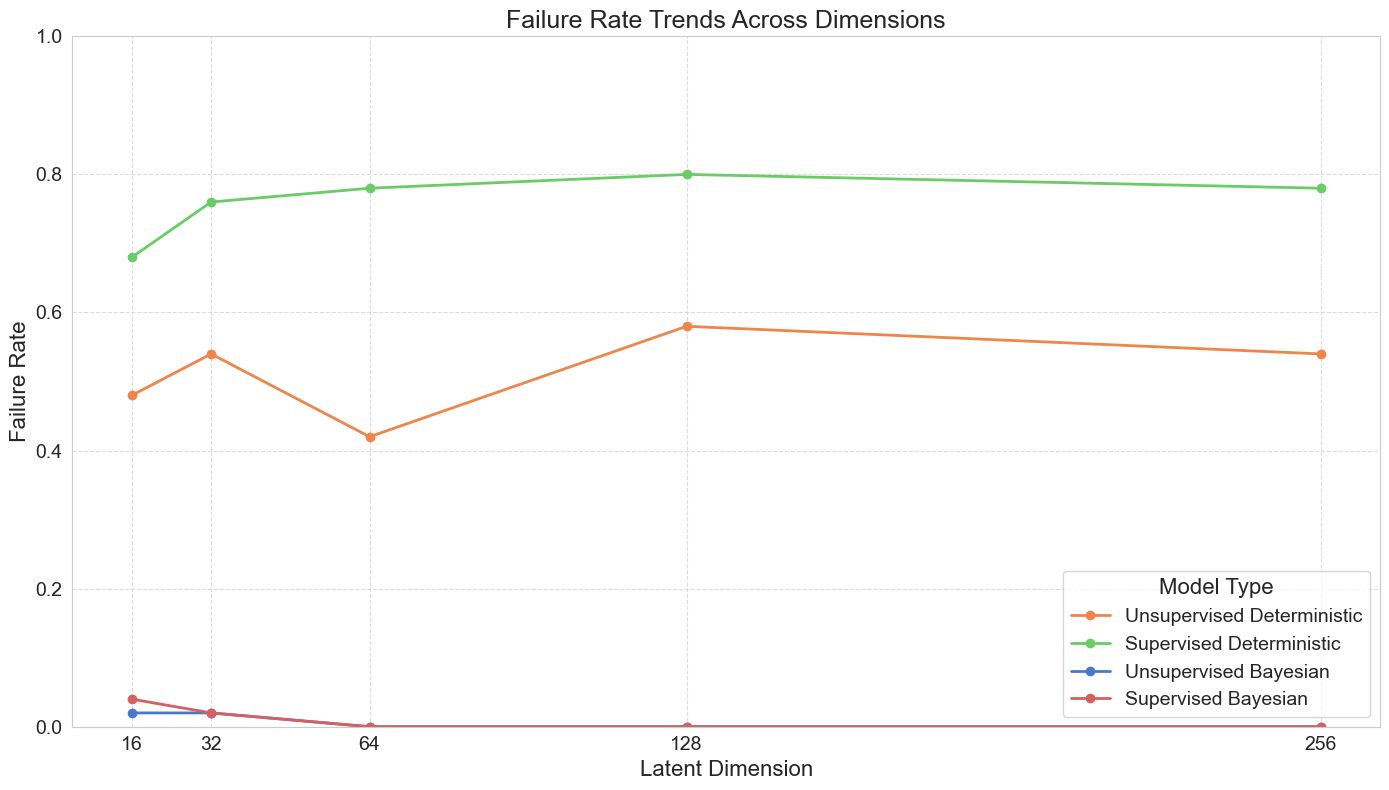

,dimension,model_type,failure_rate,sample_count
0,32,Supervised Bayesian,0.02,50
1,32,Unsupervised Deterministic,0.54,50
2,32,Supervised Deterministic,0.76,50
3,32,Unsupervised Bayesian,0.02,50
4,128,Supervised Deterministic,0.80,50
5,128,Supervised Bayesian,0.00,50
6,128,Unsupervised Deterministic,0.58,50
7,128,Unsupervised Bayesian,0.00,50
8,16,Supervised Bayesian,0.04,50
9,16,Supervised Deterministic,0.68,50


In [11]:
failure_df = calculate_failure_rates(results_dict)
plot_failure_rates(failure_df)

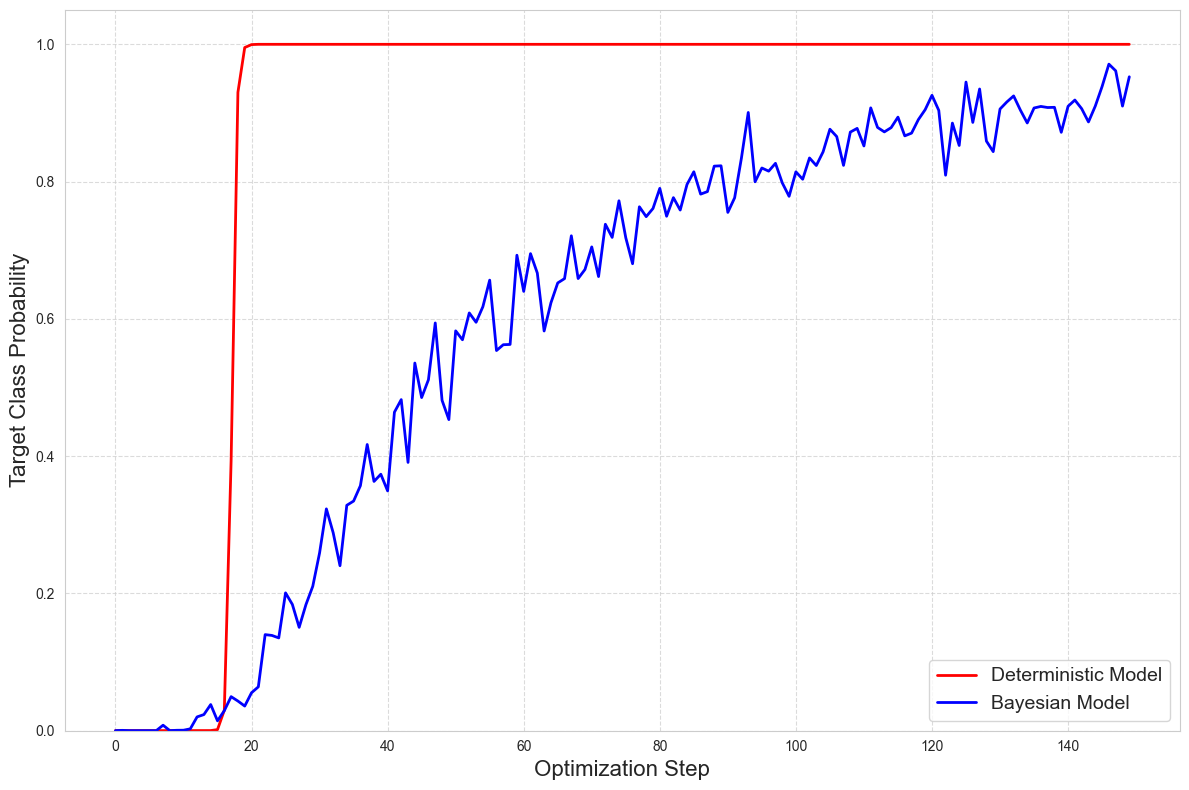

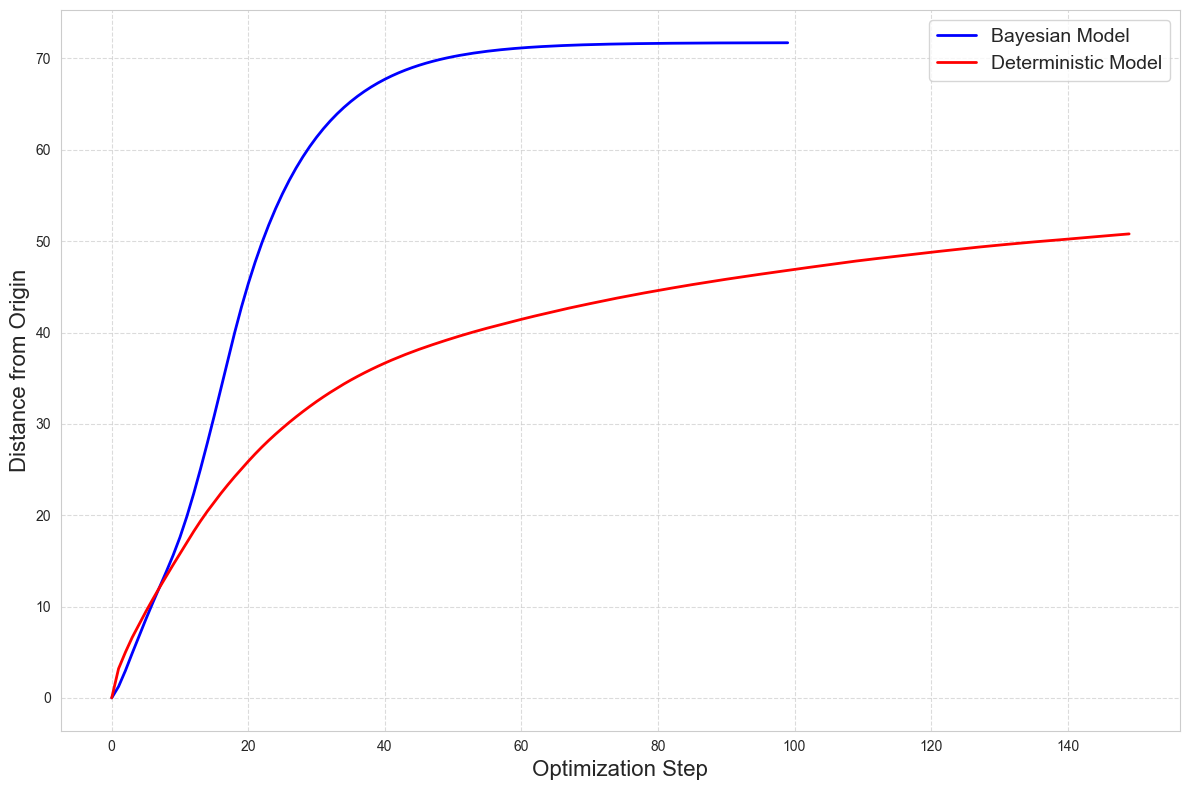

In [12]:
# Plot the target class probability vs optimization steps from step_data.csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the step data
step_data = pd.read_csv('step_data.csv')

# Create a figure for target class probability
plt.figure(figsize=(12, 8))

# Extract data for plotting - using all 150 steps
bayes_steps = step_data['Step'].iloc[:150]  
bayes_probs = step_data['Target Class Prob'].iloc[:150]

det_steps = step_data['Step.1'].iloc[:150]  
det_probs = step_data['Target_Class_Prob'].iloc[:150]

# Plot the lines without markers
plt.plot(bayes_steps, bayes_probs, 'r-', linewidth=2, label='Deterministic Model')
plt.plot(det_steps, det_probs, 'b-', linewidth=2, label='Bayesian Model')

# Add labels and title
plt.xlabel('Optimization Step', fontsize=16)
plt.ylabel('Target Class Probability', fontsize=16)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=14)

# Set y-axis limits
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Plot the distance vs optimization steps
plt.figure(figsize=(12, 8))

# Extract distance data - using all 150 steps
bayes_distance = step_data['Distance'].iloc[:150]
det_distance = step_data['Distance.1'].iloc[:150]

# Plot the lines without markers
plt.plot(bayes_steps, bayes_distance, 'b-', linewidth=2, label='Bayesian Model')
plt.plot(det_steps, det_distance, 'r-', linewidth=2, label='Deterministic Model')

# Add labels and title
plt.xlabel('Optimization Step', fontsize=16)
plt.ylabel('Distance from Origin', fontsize=16)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()


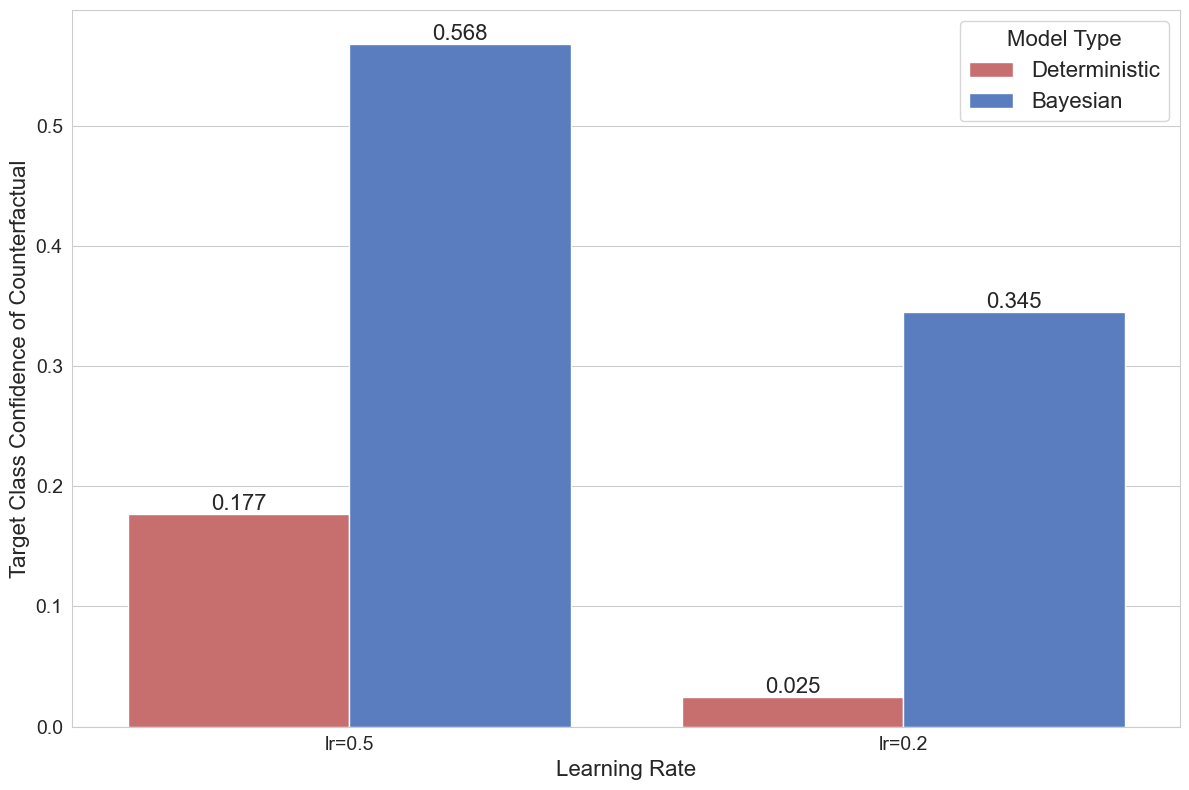

In [10]:
# Create a DataFrame for the parameter values
param_data = pd.DataFrame({
    'Parameter': ['lr=0.5', 'lr=0.2'],
    'Deterministic': [0.177, 0.025],
    'Bayesian': [0.568, 0.345]
})

# Reshape the data for plotting
param_data_melted = pd.melt(param_data, id_vars=['Parameter'], 
                           value_vars=['Deterministic', 'Bayesian'],
                           var_name='Model Type', value_name='Value')

# Set up the style
sns.set_style("whitegrid")

# Create color palette with specified colors in muted tones
palette = sns.color_palette("muted", 4)
# Use blue and red from the palette for consistency but swap them again
custom_palette = [palette[3], palette[0]]  # red, blue in muted tones

# Create the bar chart
plt.figure(figsize=(12, 8))

ax = sns.barplot(x='Parameter', y='Value', hue='Model Type', data=param_data_melted,
                palette=custom_palette)

# plt.title('Parameter Values by Model Type', fontsize=18)
plt.xlabel('Learning Rate', fontsize=16)
plt.ylabel('Target Class Confidence of Counterfactual', fontsize=16)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=16)

# Adjust legend and tick labels
plt.legend(title='Model Type', fontsize=16, title_fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()